# **AUTOENCODER**

Khởi tạo mô hình

In [ ]:

from keras.datasets import mnist
import numpy as np
import keras
from keras import layers

Khởi tạo dữ liệu

In [ ]:
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train.shape[1:])
print(x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 784)
(10000, 784)


Xây dựng mô hình Autoencoder

In [ ]:
from keras.src.regularizers.regularizers import L1

# Kích thước lớp ẩn ở giữa. Bức ảnh ban đầu sẽ bị ép lại còn 32 đặc trưng
encoding_dim = 32


input_img = keras.Input(shape=(784,))

# Mã hóa Dense với 32 neuron
encoded = layers.Dense(units=encoding_dim ,activation="relu")(input_img)

# Giải mã lại với số neuron bằng kích thước ảnh gốc
decoded = layers.Dense(units=784, activation="sigmoid")(encoded)

# Tạo mô hình, nhận dữ liệu từ input_img và kết thúc tại decodeđ
# Mô hình tổng thể
autoencoder = keras.Model(input_img, decoded)

# Mô hình mã hóa
encoder = keras.Model(input_img, encoded)

# Mô hình giải mã
encoded_input = keras.Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))


Huấn luyện mô hình

In [ ]:
autoencoder.compile(optimizer="adam", loss="binary_crossentropy", metrics=['accuracy'])
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))


Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.0102 - loss: 0.2790 - val_accuracy: 0.0140 - val_loss: 0.1884
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0117 - loss: 0.1695 - val_accuracy: 0.0100 - val_loss: 0.1532
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.0108 - loss: 0.1442 - val_accuracy: 0.0110 - val_loss: 0.1332
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.0104 - loss: 0.1280 - val_accuracy: 0.0108 - val_loss: 0.1206
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0106 - loss: 0.1172 - val_accuracy: 0.0095 - val_loss: 0.1116
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0100 - loss: 0.1097 - val_accuracy: 0.0115 - val_loss: 0.1054
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.0109 - loss: 0.1045 - val_accuracy: 0.0124 - val_loss: 0.1013
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0110 - loss: 0.1010 - val_accu

Dự báo loại ảnh sử dụng Autoencoder

In [ ]:
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


Hiển thị ảnh từ mô hình

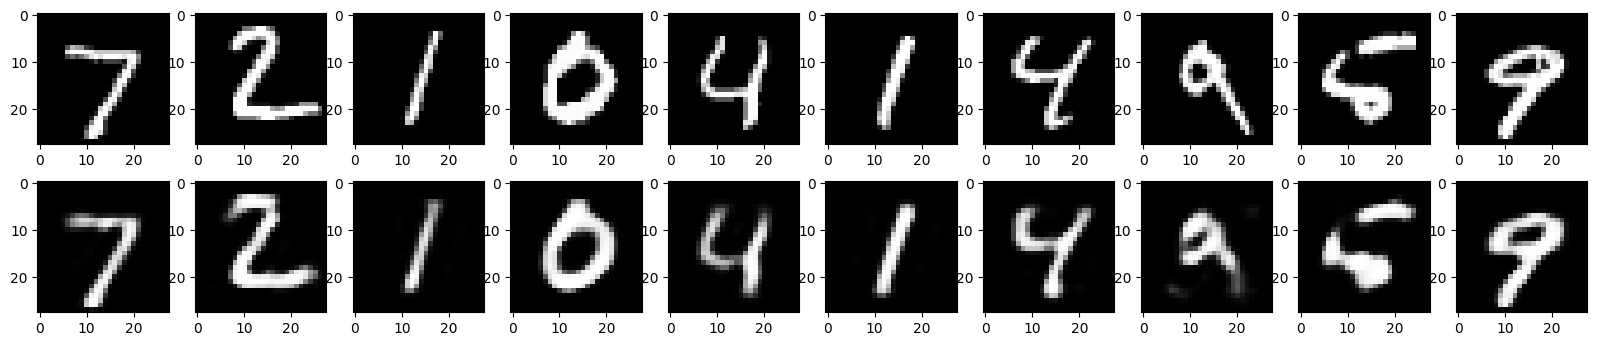

In [ ]:
import matplotlib.pyplot as plt
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()

plt.show()

Mô hình encoder có thêm L1

In [ ]:
from keras.src.regularizers.regularizers import L1
encoding_dim = 32
input_img = keras.Input(shape=(784,))

# L1 ảnh hưởng trực tiếp đến giá trị đầu ra, những neuron nào nổi bật để nhận diện sẽ được giữ lại
encoded = layers.Dense(encoding_dim, activity_regularizer=L1 ,activation="relu")(input_img)
decoded = layers.Dense(784, activation="sigmoid")(encoded)

autoencoder = keras.Model(input_img, decoded)

encoder = keras.Model(input_img, encoded)

encoded_input = keras.Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

In [ ]:
autoencoder.compile(optimizer="adam", loss="binary_crossentropy", metrics=['accuracy'])
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.0145 - loss: 0.8999 - val_accuracy: 0.0161 - val_loss: 0.6162
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0151 - loss: 0.5838 - val_accuracy: 0.0161 - val_loss: 0.5538
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0150 - loss: 0.5277 - val_accuracy: 0.0161 - val_loss: 0.5039
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.0150 - loss: 0.4829 - val_accuracy: 0.0161 - val_loss: 0.4638
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.0150 - loss: 0.4467 - val_accuracy: 0.0161 - val_loss: 0.4314
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0150 - loss: 0.4174 - val_accuracy: 0.0161 - val_loss: 0.4050
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0149 - loss: 0.3935 - val_accuracy: 0.0161 - val_loss: 0.3834
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.0150 - loss: 0.3739 - val_accu

Thêm layer

In [ ]:
input_img = keras.Input(shape=(784,))
encoded = layers.Dense(128, activation="relu")(input_img)
encoded = layers.Dense(64, activation="relu")(encoded)
encoded = layers.Dense(32, activation="relu")(encoded)

decoded = layers.Dense(784, activation="sigmoid")(encoded)

autoencoder = keras.Model(input_img, decoded)
encoder = keras.Model(input_img, encoded)
encoded_input = keras.Input(shape=(32,))
decoder_layer = autoencoder.layers[-1]
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

# **RNN**

In [2]:
from pandas import read_csv
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Dense, SimpleRNN
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math
import matplotlib.pyplot as plt



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Mô hình RNN

In [6]:
def createRNN(hidden_units, dense_units, input_shape, activation):
    model = Sequential()
    model.add(SimpleRNN(hidden_units, input_shape=input_shape, activation=activation[0]))
    model.add(Dense(dense_units, activation=activation[1]))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Chạy thử nghiệm
demoRNN = createRNN(2, 1, (3, 1), ['linear', 'linear'])
demoRNN.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (44.00 B)

 Trainable params: 11 (44.00 B)

 Non-trainable params: 0 (0.00 B)

Tham số RNN

In [10]:
wx = demoRNN.get_weights()[0]
wh = demoRNN.get_weights()[1]
bh = demoRNN.get_weights()[2]
wy = demoRNN.get_weights()[3]
by = demoRNN.get_weights()[4]

print('wx = ',wx)
print('wh = ',wh)
print('bh = ',bh)
print('wy = ',wy)
print('by = ',by)

wx =  [[-1.2581997   0.05306292]]
wh =  [[ 0.5700022  -0.82164323]
 [ 0.82164323  0.5700021 ]]
bh =  [0. 0.]
wy =  [[-0.65906507]
 [-0.09025121]]
by =  [0.]


Tính vector cho tần recurrent

In [12]:
x = np.array([1,2,3])

x_input = np.reshape(x, (1,3,1))
y_predict_model = demoRNN.predict(x_input)

m = 2
h0 = np.zeros(m)
h1 = np.dot(x[0], wx) + bh + h0
h2 = np.dot(x[1], wx) + np.dot(h1, wh) + bh
h3 = np.dot(x[2], wx) + np.dot(h2, wh) + bh

o3 = np.dot(h3, wy) + by

print('h1 =', h1)
print('h2 =', h2)
print('h3 =', h3)

print('Prediction of model:', y_predict_model)
print('Prediction from computation:', o3)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
h1 = [[-1.25819969  0.05306292]]
h2 = [[-3.18997719  1.17016307]]
h3 = [[-4.63143652  3.4472073 ]]
Prediction of model: [[2.7413034]]
Prediction from computation: [[2.7413034]]


Áp dụng RNN

Đọc dữ liệu

In [16]:
import pandas as pd

def get_train_test(url, split_percent=0.8):
    df = pd.read_csv(url, usecols=[1], engine='python')
    data = np.array(df.values.astype('float32'))
    scaler = MinMaxScaler(feature_range=(0, 1))
    data = scaler.fit_transform(data).flatten()

    n = len(data)

    split = int(n * split_percent)
    train_data = data[range(split)]
    test_data = data[split:]
    return train_data, test_data, data

sunspots_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv'
train_data, test_data, data = get_train_test(sunspots_url)

Chuẩn bị dữ liệu

In [18]:
def get_XY(dat, time_steps):
    #indices target arrays
    y_ind = np.arange(time_steps, len(dat), time_steps)
    Y = dat[y_ind]

    #prepare X
    row_x = len(Y)
    X = dat[range(time_steps * row_x)]
    X = np.reshape(X, (row_x, time_steps, 1))
    return X, Y

time_steps = 12
trainX, trainY = get_XY(train_data, time_steps)
testX, testY = get_XY(test_data, time_steps)

Huấn luyện

In [19]:
model = createRNN(hidden_units=3, dense_units=1, input_shape=(time_steps,1), activation=['tanh', 'tanh'])
model_fit = model.fit(trainX, trainY, epochs=20,verbose=1)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0210
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0184
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0172
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0159 
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0150 
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0141 
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0134 
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0127 
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0121 
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0116 
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0112 
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0108
Epoch 13/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0104 
Epoch 14/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0100 
Epoch 15/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0097 
Epoch 16/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/s

Tính hiệu quả model

In [22]:
def print_error(trainX, trainY, testX, testY, model):
    # Tính toán lỗi Mean Squared Error (MSE) rồi lấy căn bậc hai (RMSE)
    train_rmse = math.sqrt(mean_squared_error(trainY, train_predict))
    test_rmse = math.sqrt(mean_squared_error(testY, test_predict))

    # In kết quả ra màn hình
    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")

# Dự đoán kết quả trên tập Train và tập Test
train_predict = model.predict(trainX)
test_predict = model.predict(testX)

# Gọi hàm in kết quả sai số
print_error(trainX, trainY, testX, testY, model)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Train RMSE: 0.0915
Test RMSE: 0.0981


Đánh giá kết quả

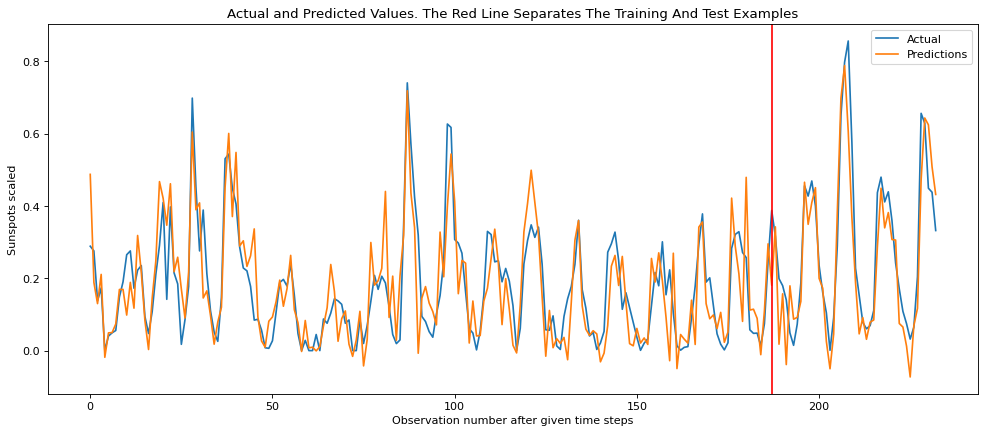

In [23]:
def plot_result(trainY, testY, train_predict, test_predict):
    actual = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)

    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual)
    plt.plot(range(rows), predictions)
    plt.axvline(x=len(trainY), color='r')
    plt.legend(['Actual', 'Predictions'])
    plt.xlabel('Observation number after given time steps')
    plt.ylabel('Sunspots scaled')
    plt.title('Actual and Predicted Values. The Red Line Separates The Training And Test Examples')
    plt.show()

plot_result(trainY, testY, train_predict, test_predict)

Bài tập 1

--- Bắt đầu huấn luyện mô hình RNN ---
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3262
Epoch 2/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0492
Epoch 3/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0321
Epoch 4/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0268
Epoch 5/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0228
Epoch 6/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0186
Epoch 7/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0160
Epoch 8/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0124
Epoch 9/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0102
Epoch 10/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0084
Epoch 11/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0072
Epoch 12/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0065
Epoch 13/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0060
Epoch 14/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0059
Epoch 15/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0055
Epoch 16/30
42/42 ━━━━━━━━━━━━

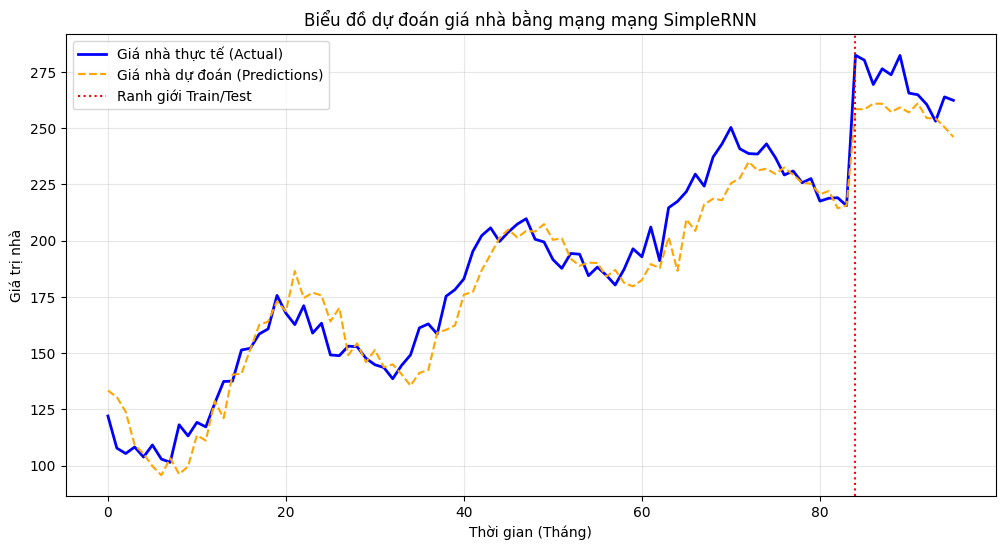

In [24]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

#  ---- XỬ LÝ DỮ LIỆU ----
def generate_housing_data():
    np.random.seed(42)
    time = np.arange(0, 120)
    price = 100 + 1.5 * time + 20 * np.sin(time / 4) + np.random.normal(0, 5, len(time))
    return price

# Hàm chia tập Train / Test và chuẩn hóa dữ liệu về khoảng [0, 1]
def preprocess_data(raw_data, split_percent=0.8):
    # Chuyển thành mảng 2D cho MinMaxScaler
    data = np.array(raw_data, dtype='float32').reshape(-1, 1)

    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(data).flatten()

    n = len(data_scaled)
    split = int(n * split_percent)

    train_data = data_scaled[:split]
    test_data = data_scaled[split:]
    return train_data, test_data, data_scaled, scaler

# Hàm tạo cấu trúc X (các bước thời gian quá khứ) và Y (giá nhà tương lai cần dự đoán)
def get_XY(dat, time_steps):
    X, Y = [], []
    for i in range(len(dat) - time_steps):
        X.append(dat[i:(i + time_steps)])
        Y.append(dat[i + time_steps])

    X = np.array(X)
    Y = np.array(Y)

    # Định dạng lại cấu trúc: (samples, time_steps, features)
    X = np.reshape(X, (X.shape[0], time_steps, 1))
    return X, Y

# --- KHAI BÁO CẤU TRÚC MÔ HÌNH RNN ---
def create_RNN(hidden_units, dense_units, input_shape, activation):
    model = Sequential()
    model.add(SimpleRNN(hidden_units, input_shape=input_shape, activation=activation[0]))
    # Lớp Dense đưa ra đầu ra là 1 giá trị dự đoán duy nhất cho tháng kế tiếp
    model.add(Dense(dense_units, activation=activation[1]))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model


# --- HUẤN LUYỆN ---
# tạo dữ liệu giả
raw_price_data = generate_housing_data()

train_data, test_data, all_data_scaled, scaler = preprocess_data(raw_price_data, split_percent=0.8)

# Thiết lập số bước thời gian nhìn về quá khứ (Ví dụ: Dựa vào giá nhà 12 tháng trước để đoán tháng thứ 13)
time_steps = 12
trainX, trainY = get_XY(train_data, time_steps)
testX, testY = get_XY(test_data, time_steps)

model = create_RNN(hidden_units=6, dense_units=1, input_shape=(time_steps, 1), activation=['tanh', 'linear'])

# huấn luyện mô hình
print("--- Bắt đầu huấn luyện mô hình RNN ---")
model.fit(trainX, trainY, epochs=30, batch_size=2, verbose=1)

# --- ĐÁNH GIÁ ---

def print_error(trainY, testY, train_predict, test_predict, scaler):
    # Chuyển giá trị được scale sang giá trị ban đầu
    trainY_orig = scaler.inverse_transform(trainY.reshape(-1, 1))
    train_predict_orig = scaler.inverse_transform(train_predict)

    testY_orig = scaler.inverse_transform(testY.reshape(-1, 1))
    test_predict_orig = scaler.inverse_transform(test_predict)

    train_rmse = math.sqrt(mean_squared_error(trainY_orig, train_predict_orig))
    test_rmse = math.sqrt(mean_squared_error(testY_orig, test_predict_orig))

    print("\n--- ĐÁNH GIÁ SAI SỐ KHỚP VỚI ĐƠN VỊ THỰC TẾ ---")
    print('Train RMSE: %.3f (Đơn vị gốc)' % (train_rmse))
    print('Test RMSE: %.3f (Đơn vị gốc)' % (test_rmse))

    return trainY_orig, testY_orig, train_predict_orig, test_predict_orig

# Hàm vẽ biểu đồ trực quan hóa
def plot_result(trainY, testY, train_predict, test_predict):
    actual = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)

    plt.figure(figsize=(12, 6), dpi=100)
    plt.plot(range(rows), actual, label='Giá nhà thực tế (Actual)', color='blue', linewidth=2)
    plt.plot(range(rows), predictions, label='Giá nhà dự đoán (Predictions)', color='orange', linestyle='--')

    # Đường thẳng đỏ phân tách ranh giới dữ liệu Train và Test
    plt.axvline(x=len(trainY), color='red', linestyle=':', label='Ranh giới Train/Test')

    plt.legend()
    plt.xlabel('Thời gian (Tháng)')
    plt.ylabel('Giá trị nhà')
    plt.title('Biểu đồ dự đoán giá nhà bằng mạng mạng SimpleRNN')
    plt.grid(True, alpha=0.3)
    plt.show()

train_predict = model.predict(trainX)
test_predict = model.predict(testX)

trainY_orig, testY_orig, train_predict_orig, test_predict_orig = print_error(
    trainY, testY, train_predict, test_predict, scaler
)

plot_result(trainY_orig, testY_orig, train_predict_orig, test_predict_orig)